
# GOOG Trading Strategies Comparison

## Strategies

We compare three strategies:

1. **Buy and Hold**
   - Buy 100 shares on the first day
   - Sell on the last day

2. **Random Strategy**
   - Randomly enter and exit the market
   - Seed = 6666 for reproducibility

3. **Double Moving Average Strategy**
   - Short Moving Average = 50 days
   - Long Moving Average = 200 days
   - Buy when SMA50 crosses above SMA200
   - Sell when SMA50 crosses below SMA200

---

## Performance Metrics

Before comparing final portfolio values, we compute the **Sharpe Ratio**.

The Sharpe Ratio measures risk-adjusted return:

Sharpe Ratio = (Mean Daily Return / Std Daily Return) × sqrt(252)

where 252 is the approximate number of trading days per year.

Higher Sharpe Ratios indicate better risk-adjusted performance.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import random

plt.style.use('default')


In [2]:

start_date = '2001-01-01'
end_date = '2018-01-01'

goog_data = yf.download(
    'GOOG',
    start=start_date,
    end=end_date,
    auto_adjust=True,
    multi_level_index=False
)

close_price = goog_data['Close']

initial_capital = 10000
shares = 100


[*********************100%***********************]  1 of 1 completed


## Helper Function

In [3]:

def build_portfolio(signal, close_price, initial_capital=10000, shares=100):

    portfolio = pd.DataFrame(index=close_price.index)

    portfolio['signal'] = signal
    portfolio['orders'] = portfolio['signal'].diff()

    portfolio['position'] = portfolio['signal'] * shares

    portfolio['holdings'] = (
        portfolio['position'] * close_price
    )

    trade_value = (
        portfolio['orders'] * shares * close_price
    )

    portfolio['cash'] = (
        initial_capital - trade_value.cumsum().fillna(0)
    )

    portfolio['total'] = (
        portfolio['cash'] + portfolio['holdings']
    )

    portfolio['returns'] = (
        portfolio['total'].pct_change()
    )

    return portfolio


## Strategy 1 - Buy and Hold

In [4]:

buy_hold_signal = pd.Series(
    1,
    index=close_price.index
)

buy_hold_signal.iloc[-1] = 0

buy_hold = build_portfolio(
    buy_hold_signal,
    close_price,
    initial_capital,
    shares
)


## Strategy 2 - Random

In [5]:

random.seed(6666)

random_signal = pd.Series(
    [random.randint(0,1) for _ in range(len(close_price))],
    index=close_price.index
)

random_portfolio = build_portfolio(
    random_signal,
    close_price,
    initial_capital,
    shares
)


## Strategy 3 - Double Moving Average

In [6]:

signals_ma = pd.DataFrame(index=close_price.index)

signals_ma['SMA50'] = close_price.rolling(50).mean()
signals_ma['SMA200'] = close_price.rolling(200).mean()

signals_ma['signal'] = 0

signals_ma.loc[
    signals_ma['SMA50'] > signals_ma['SMA200'],
    'signal'
] = 1

ma_portfolio = build_portfolio(
    signals_ma['signal'],
    close_price,
    initial_capital,
    shares
)

signals_ma.tail()


,SMA50,SMA200,signal
Date,,,
2017-12-22,50.742597,46.791178,1
2017-12-26,50.809071,46.843517,1
2017-12-27,50.865940,46.894009,1
2017-12-28,50.921410,46.943805,1
2017-12-29,50.974532,46.992778,1


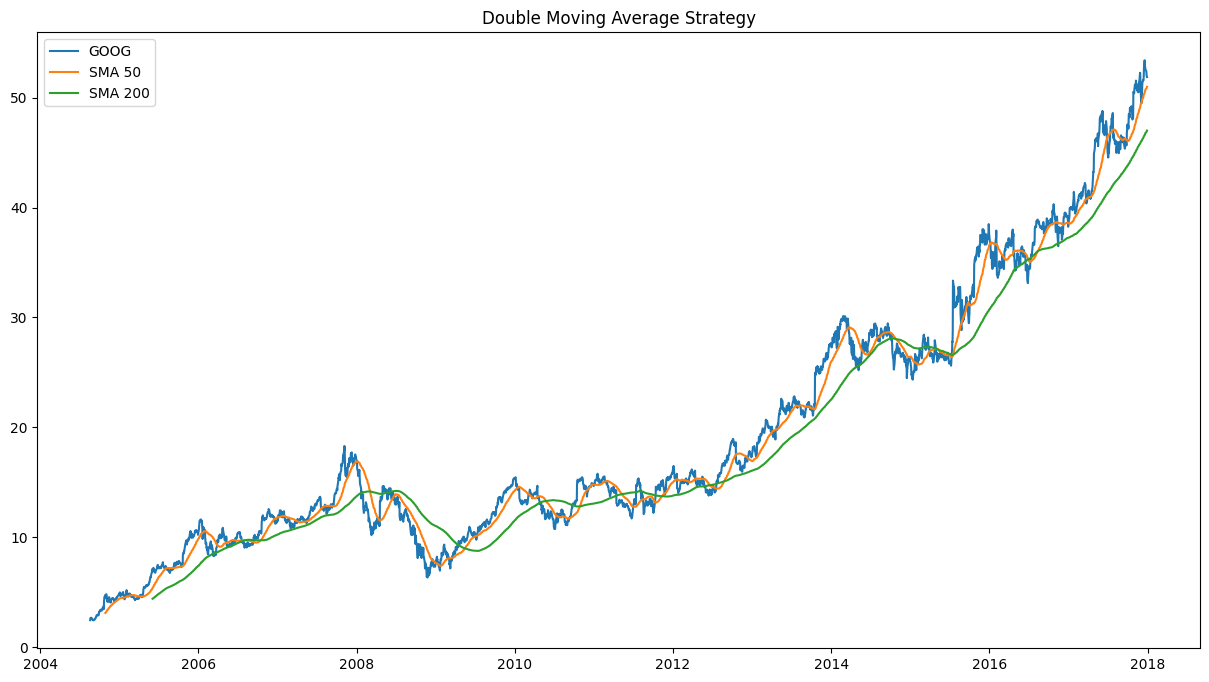

In [7]:

fig, ax = plt.subplots(figsize=(15,8))

ax.plot(close_price, label='GOOG')

ax.plot(
    signals_ma['SMA50'],
    label='SMA 50'
)

ax.plot(
    signals_ma['SMA200'],
    label='SMA 200'
)

ax.set_title('Double Moving Average Strategy')

ax.legend()

plt.show()



## Sharpe Ratio Calculation

The Sharpe Ratio measures return per unit of risk.

A larger Sharpe Ratio indicates a better trade-off between return and volatility.


In [8]:

def sharpe_ratio(portfolio):

    returns = portfolio['returns'].dropna()

    if returns.std() == 0:
        return np.nan

    return np.sqrt(252) * (
        returns.mean() / returns.std()
    )


In [9]:

sharpe_buy_hold = sharpe_ratio(buy_hold)
sharpe_random = sharpe_ratio(random_portfolio)
sharpe_ma = sharpe_ratio(ma_portfolio)

comparison = pd.DataFrame({
    'Final Value': [
        buy_hold['total'].iloc[-1],
        random_portfolio['total'].iloc[-1],
        ma_portfolio['total'].iloc[-1]
    ],
    'Sharpe Ratio': [
        sharpe_buy_hold,
        sharpe_random,
        sharpe_ma
    ]
}, index=[
    'Buy and Hold',
    'Random',
    'Double MA'
])

comparison.sort_values(
    'Sharpe Ratio',
    ascending=False
)


,Final Value,Sharpe Ratio
Buy and Hold,15186.274338,0.738029
Random,12645.388293,0.604316
Double MA,12538.364220,0.451245


## Portfolio Value Comparison

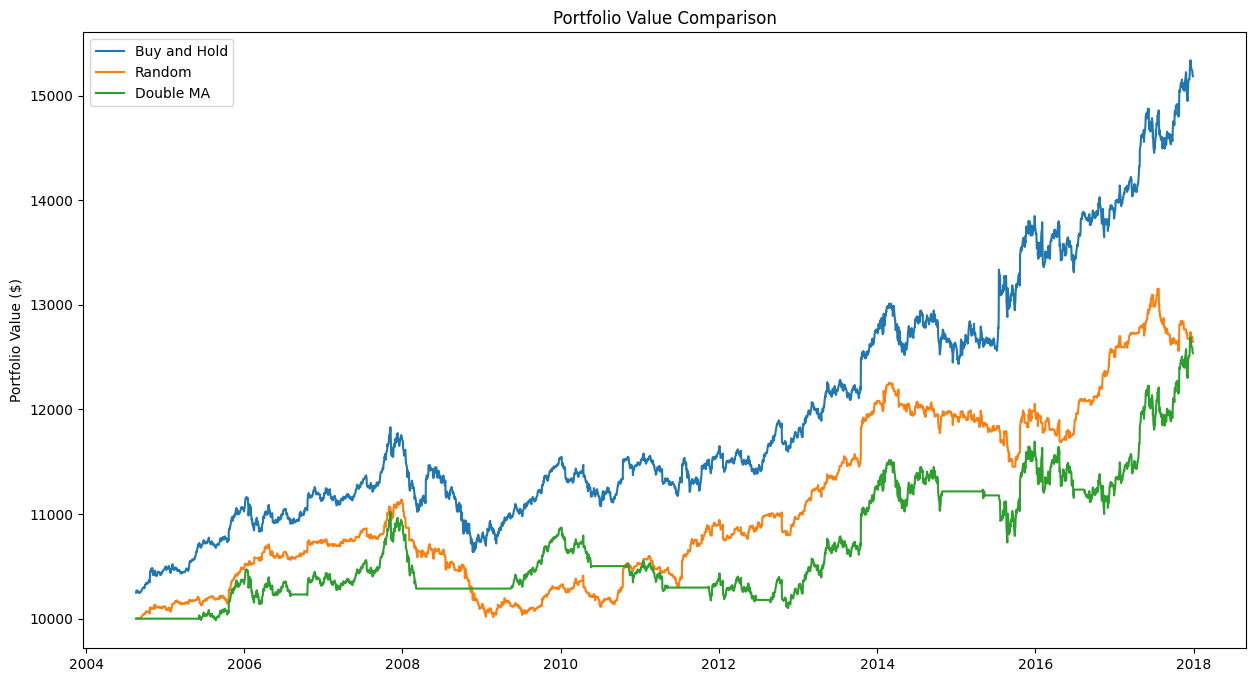

In [10]:

fig, ax = plt.subplots(figsize=(15,8))

ax.plot(
    buy_hold['total'],
    label='Buy and Hold'
)

ax.plot(
    random_portfolio['total'],
    label='Random'
)

ax.plot(
    ma_portfolio['total'],
    label='Double MA'
)

ax.set_title(
    'Portfolio Value Comparison'
)

ax.set_ylabel('Portfolio Value ($)')

ax.legend()

plt.show()



## Discussion

Typical observations:

- Buy-and-Hold often performs very well in strongly trending stocks.
- Random trading generally produces poor Sharpe Ratios because there is no informational edge.
- Double Moving Average strategies often reduce drawdowns and can improve risk-adjusted returns.

The Sharpe Ratio is usually a better metric than final portfolio value because it accounts for both return and risk.
